In [38]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [20]:
df = pd.read_csv('UnifiedDataset.csv')

In [21]:
print(df.shape)
df.head()

(9999, 150)


,Country,Year,Gender,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,...,Cereal Consumption Rye,Cereal Consumption Barley,Cereal Consumption Sorghum,Cereal Consumption Maize,Cereal Consumption Wheat,Cereal Consumption Rice,Diet Calories Animal Protein,Diet Calories Plant Protein,Diet Calories Fat,Diet Calories Carbohydrates
0,Afghanistan,1990,Both sexes,50.331,120.4,111.2,130.9,177.7,162.5,194.3,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
1,Afghanistan,1990,Female,51.442,114.2,105.1,124.7,173.1,158.0,189.7,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
2,Afghanistan,1990,Male,49.281,126.2,116.4,137.5,182.0,166.6,199.3,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
3,Afghanistan,1991,Both sexes,50.999,116.8,108.2,126.2,171.7,157.6,186.9,...,NaN,94.0,NaN,164.0,1043.0,159.0,64.96,173.68,370.08,1435.28
4,Afghanistan,1991,Female,52.119,110.7,102.1,120.4,167.1,153.0,182.6,...,NaN,94.0,NaN,164.0,1043.0,159.0,64.96,173.68,370.08,1435.28


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Columns: 150 entries,  Country to Diet Calories Carbohydrates
dtypes: float64(147), int64(1), object(2)
memory usage: 11.4+ MB


In [48]:
def categorize_risk(life_expectancy):
    if pd.isna(life_expectancy):
        return None
    if life_expectancy < 55:
        return 'High Risk'
    elif life_expectancy < 70:
        return 'Medium Risk'
    else:
        return 'Low Risk'

In [51]:
df['Health_Risk_Level'] = df['Life Expectancy'].apply(categorize_risk)


In [52]:
feature_columns = [
    'Year', 'Gender', 'Infant Mortality Rate', 'Under 5 Mortality Rate',
    'Suicides Rate', 'Alcohol Abuse', 'Tobacco Prevalence', 
    '% Death Cardiovascular', 'Incidence of Malaria', 'Incidence of Tuberculosis',
    '% of Births Attended By Skilled Personal', 'Universal Heath Care Coverage',
    'Air Pollution Death Rate Total', 'GDP per Capita', '% Population $1.90 a day',
    'Doctors', 'Nurses and Midwifes', '% Population Aged 0-14', '% Population Aged 65+'
]

In [53]:
df_model = df[feature_columns + ['Health_Risk_Level']].copy()
df_model = df_model.dropna(subset=['Health_Risk_Level'])

In [54]:
label_encoder = LabelEncoder()
df_model['Gender_encoded'] = label_encoder.fit_transform(df_model['Gender'])

In [55]:
X = df_model.drop(['Health_Risk_Level', 'Gender'], axis=1)
y = df_model['Health_Risk_Level']
y_encoded = label_encoder.fit_transform(y)


In [56]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)


In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [58]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_scaled, y_encoded, df_model.index, test_size=0.2, random_state=42, stratify=y_encoded
)


In [59]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

In [62]:
rf_classifier.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [63]:
y_pred = rf_classifier.predict(X_test)

In [64]:
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

# OUTPUT 1: Predicted vs Actual Risk Levels for sample of data
print("=" * 60)
print("PREDICTED vs ACTUAL RISK LEVELS (Sample of 15 instances)")
print("=" * 60)

PREDICTED vs ACTUAL RISK LEVELS (Sample of 15 instances)


In [65]:
comparison_df = pd.DataFrame({
    'Index': idx_test,
    'Actual_Risk': y_test_labels,
    'Predicted_Risk': y_pred_labels
})

In [66]:
sample_comparison = comparison_df.sample(min(15, len(comparison_df)), random_state=42)
sample_comparison['Match'] = sample_comparison['Actual_Risk'] == sample_comparison['Predicted_Risk']

for idx, row in sample_comparison.iterrows():
    match_symbol = "✓" if row['Match'] else "✗"
    print(f"Index {row['Index']:6}: Actual = {row['Actual_Risk']:15} | Predicted = {row['Predicted_Risk']:15} [{match_symbol}]")

Index   1624: Actual = Medium Risk     | Predicted = Medium Risk     [✓]
Index   8472: Actual = Low Risk        | Predicted = Low Risk        [✓]
Index   8467: Actual = Low Risk        | Predicted = Low Risk        [✓]
Index   8400: Actual = Low Risk        | Predicted = Low Risk        [✓]
Index   5508: Actual = Low Risk        | Predicted = Low Risk        [✓]
Index   1667: Actual = Medium Risk     | Predicted = Medium Risk     [✓]
Index   1796: Actual = Medium Risk     | Predicted = Medium Risk     [✓]
Index   4418: Actual = Low Risk        | Predicted = Low Risk        [✓]
Index    116: Actual = High Risk       | Predicted = Medium Risk     [✗]
Index    540: Actual = Low Risk        | Predicted = Low Risk        [✓]
Index   8107: Actual = High Risk       | Predicted = High Risk       [✓]
Index   7373: Actual = Low Risk        | Predicted = Low Risk        [✓]
Index   9496: Actual = Low Risk        | Predicted = Low Risk        [✓]
Index   9027: Actual = Low Risk        | Predicted 

In [68]:
correct_predictions = (y_test_labels == y_pred_labels).sum()
total_predictions = len(y_test_labels)
print(f"\nOverall: {correct_predictions}/{total_predictions} correct ({correct_predictions/total_predictions:.1%})")
print("\n" + "=" * 60)
print("RISK LEVEL DISTRIBUTION ANALYSIS")
print("=" * 60)


Overall: 1793/2000 correct (89.6%)

RISK LEVEL DISTRIBUTION ANALYSIS


In [70]:
risk_levels = label_encoder.classes_
distribution_data = []

for risk in risk_levels:
    actual_count = (y_test_labels == risk).sum()
    predicted_count = (y_pred_labels == risk).sum()
    accuracy = (y_test_labels[y_test_labels == risk] == y_pred_labels[y_test_labels == risk]).mean()
    
    distribution_data.append({
        'Risk Level': risk,
        'Actual Count': actual_count,
        'Actual %': f"{actual_count/len(y_test_labels):.1%}",
        'Predicted Count': predicted_count,
        'Predicted %': f"{predicted_count/len(y_pred_labels):.1%}",
        'Accuracy for Class': f"{accuracy:.1%}" if not np.isnan(accuracy) else "N/A"
    })

distribution_df = pd.DataFrame(distribution_data)
print(distribution_df.to_string(index=False))

 Risk Level  Actual Count Actual %  Predicted Count Predicted % Accuracy for Class
  High Risk           225    11.2%              222       11.1%              87.6%
   Low Risk          1141    57.0%             1162       58.1%              93.9%
Medium Risk           634    31.7%              616       30.8%              82.8%


In [71]:
print("\nConfusion Summary:")
print("Actual → Predicted:")
confusion_summary = {}
for actual in risk_levels:
    for predicted in risk_levels:
        count = ((y_test_labels == actual) & (y_pred_labels == predicted)).sum()
        if count > 0:
            confusion_summary[f"{actual} → {predicted}"] = count

for key, value in sorted(confusion_summary.items()):
    print(f"  {key}: {value}")


Confusion Summary:
Actual → Predicted:
  High Risk → High Risk: 197
  High Risk → Low Risk: 7
  High Risk → Medium Risk: 21
  Low Risk → Low Risk: 1071
  Low Risk → Medium Risk: 70
  Medium Risk → High Risk: 25
  Medium Risk → Low Risk: 84
  Medium Risk → Medium Risk: 525


In [73]:
# OUTPUT 3: Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test_labels, y_pred_labels, 
                           target_names=label_encoder.classes_))

# Additional: Performance by Risk Level
print("\n" + "=" * 60)
print("PERFORMANCE BREAKDOWN BY RISK LEVEL")
print("=" * 60)

# Calculate precision, recall, F1 manually for better understanding
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test_labels, y_pred_labels, labels=label_encoder.classes_
)

performance_df = pd.DataFrame({
    'Risk Level': label_encoder.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print(performance_df.to_string(index=False))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   High Risk       0.89      0.88      0.88       225
    Low Risk       0.92      0.94      0.93      1141
 Medium Risk       0.85      0.83      0.84       634

    accuracy                           0.90      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.90      0.90      0.90      2000


PERFORMANCE BREAKDOWN BY RISK LEVEL
 Risk Level  Precision   Recall  F1-Score  Support
  High Risk   0.887387 0.875556  0.881432      225
   Low Risk   0.921687 0.938650  0.930091     1141
Medium Risk   0.852273 0.828076  0.840000      634


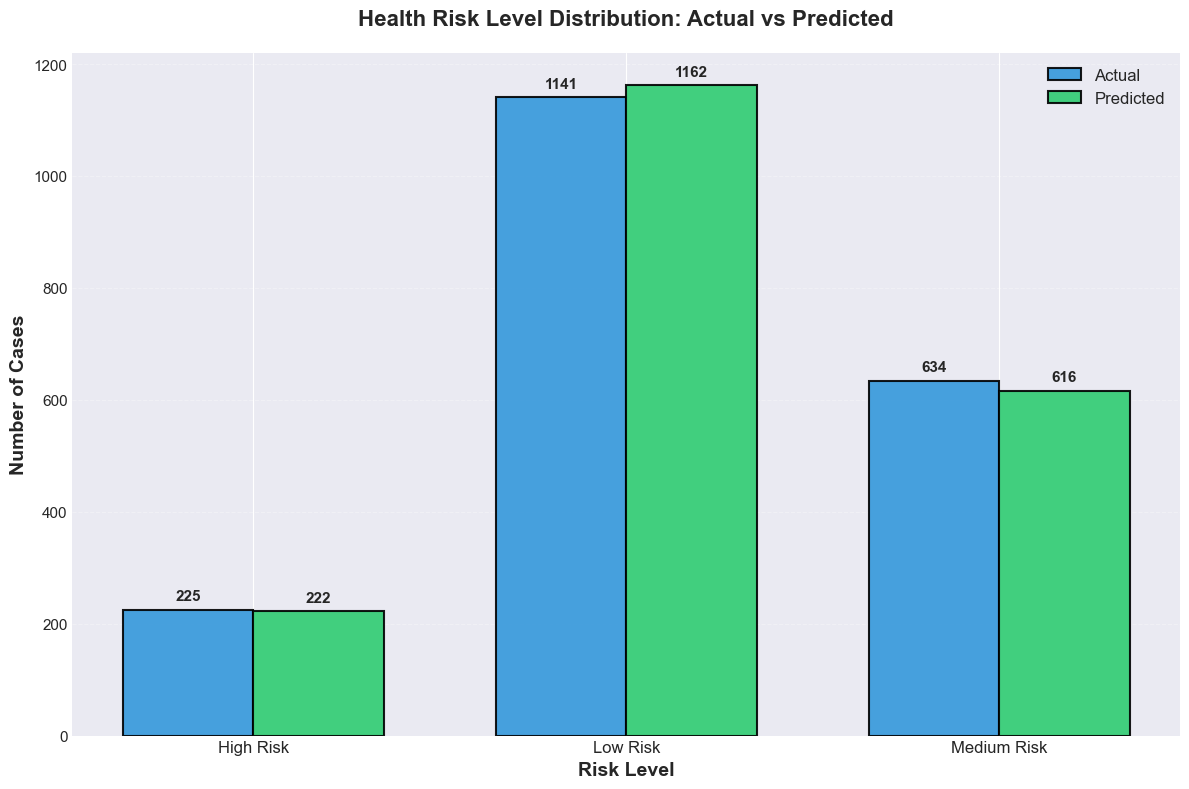

RISK DISTRIBUTION - ACTUAL vs PREDICTED
Risk Level      Actual     Predicted  Difference
----------------------------------------------------------------------
High Risk       225        222        -3        
Low Risk        1141       1162       +21        
Medium Risk     634        616        -18       
----------------------------------------------------------------------
Total           2000       2000      


In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 8))

# Calculate counts
actual_counts = pd.Series(y_test_labels).value_counts().sort_index()
predicted_counts = pd.Series(y_pred_labels).value_counts().sort_index()

# Ensure all risk levels are present
all_risk_levels = label_encoder.classes_
for risk in all_risk_levels:
    if risk not in actual_counts:
        actual_counts[risk] = 0
    if risk not in predicted_counts:
        predicted_counts[risk] = 0

# Sort by risk level order
actual_counts = actual_counts.reindex(all_risk_levels)
predicted_counts = predicted_counts.reindex(all_risk_levels)

# Set up bar positions
x = np.arange(len(all_risk_levels))
width = 0.35

# Create bars
plt.bar(x - width/2, actual_counts.values, width, label='Actual', 
        color='#3498db', edgecolor='black', linewidth=1.5, alpha=0.9)
plt.bar(x + width/2, predicted_counts.values, width, label='Predicted', 
        color='#2ecc71', edgecolor='black', linewidth=1.5, alpha=0.9)

# Customize the plot
plt.xlabel('Risk Level', fontsize=14, fontweight='bold')
plt.ylabel('Number of Cases', fontsize=14, fontweight='bold')
plt.title('Health Risk Level Distribution: Actual vs Predicted', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(x, all_risk_levels, fontsize=12)
plt.yticks(fontsize=11)

# Add legend
plt.legend(fontsize=12, loc='upper right')

# Add value labels on top of bars
for i, (actual_val, predicted_val) in enumerate(zip(actual_counts.values, predicted_counts.values)):
    plt.text(i - width/2, actual_val + max(actual_counts.max(), predicted_counts.max())*0.01, 
             str(actual_val), ha='center', va='bottom', fontsize=11, fontweight='bold')
    plt.text(i + width/2, predicted_val + max(actual_counts.max(), predicted_counts.max())*0.01, 
             str(predicted_val), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Adjust layout
plt.tight_layout()
plt.show()

# Print the exact numbers for reference
print("=" * 70)
print("RISK DISTRIBUTION - ACTUAL vs PREDICTED")
print("=" * 70)
print(f"{'Risk Level':<15} {'Actual':<10} {'Predicted':<10} {'Difference':<10}")
print("-" * 70)

for risk, actual, predicted in zip(all_risk_levels, actual_counts.values, predicted_counts.values):
    diff = predicted - actual
    diff_sign = "+" if diff > 0 else ""
    print(f"{risk:<15} {actual:<10} {predicted:<10} {diff_sign}{diff:<10}")

print("-" * 70)
print(f"{'Total':<15} {sum(actual_counts.values):<10} {sum(predicted_counts.values):<10}")
print("=" * 70)

GENERALIZED RISK DISTRIBUTION ANALYSIS

📊 DISTRIBUTION SUMMARY
      Class  Actual Count Actual %  Predicted Count Predicted % Count Diff % Diff Class Accuracy
  High Risk           225    11.2%              222       11.1%         -3  -0.2%          87.6%
   Low Risk          1141    57.0%             1162       58.1%        +21  +1.0%          93.9%
Medium Risk           634    31.7%              616       30.8%        -18  -0.9%          82.8%

📈 OVERALL STATISTICS
----------------------------------------
Total Samples: 2000
Overall Accuracy: 89.65%
Correct Predictions: 1793/2000
Balanced Accuracy: 88.08%


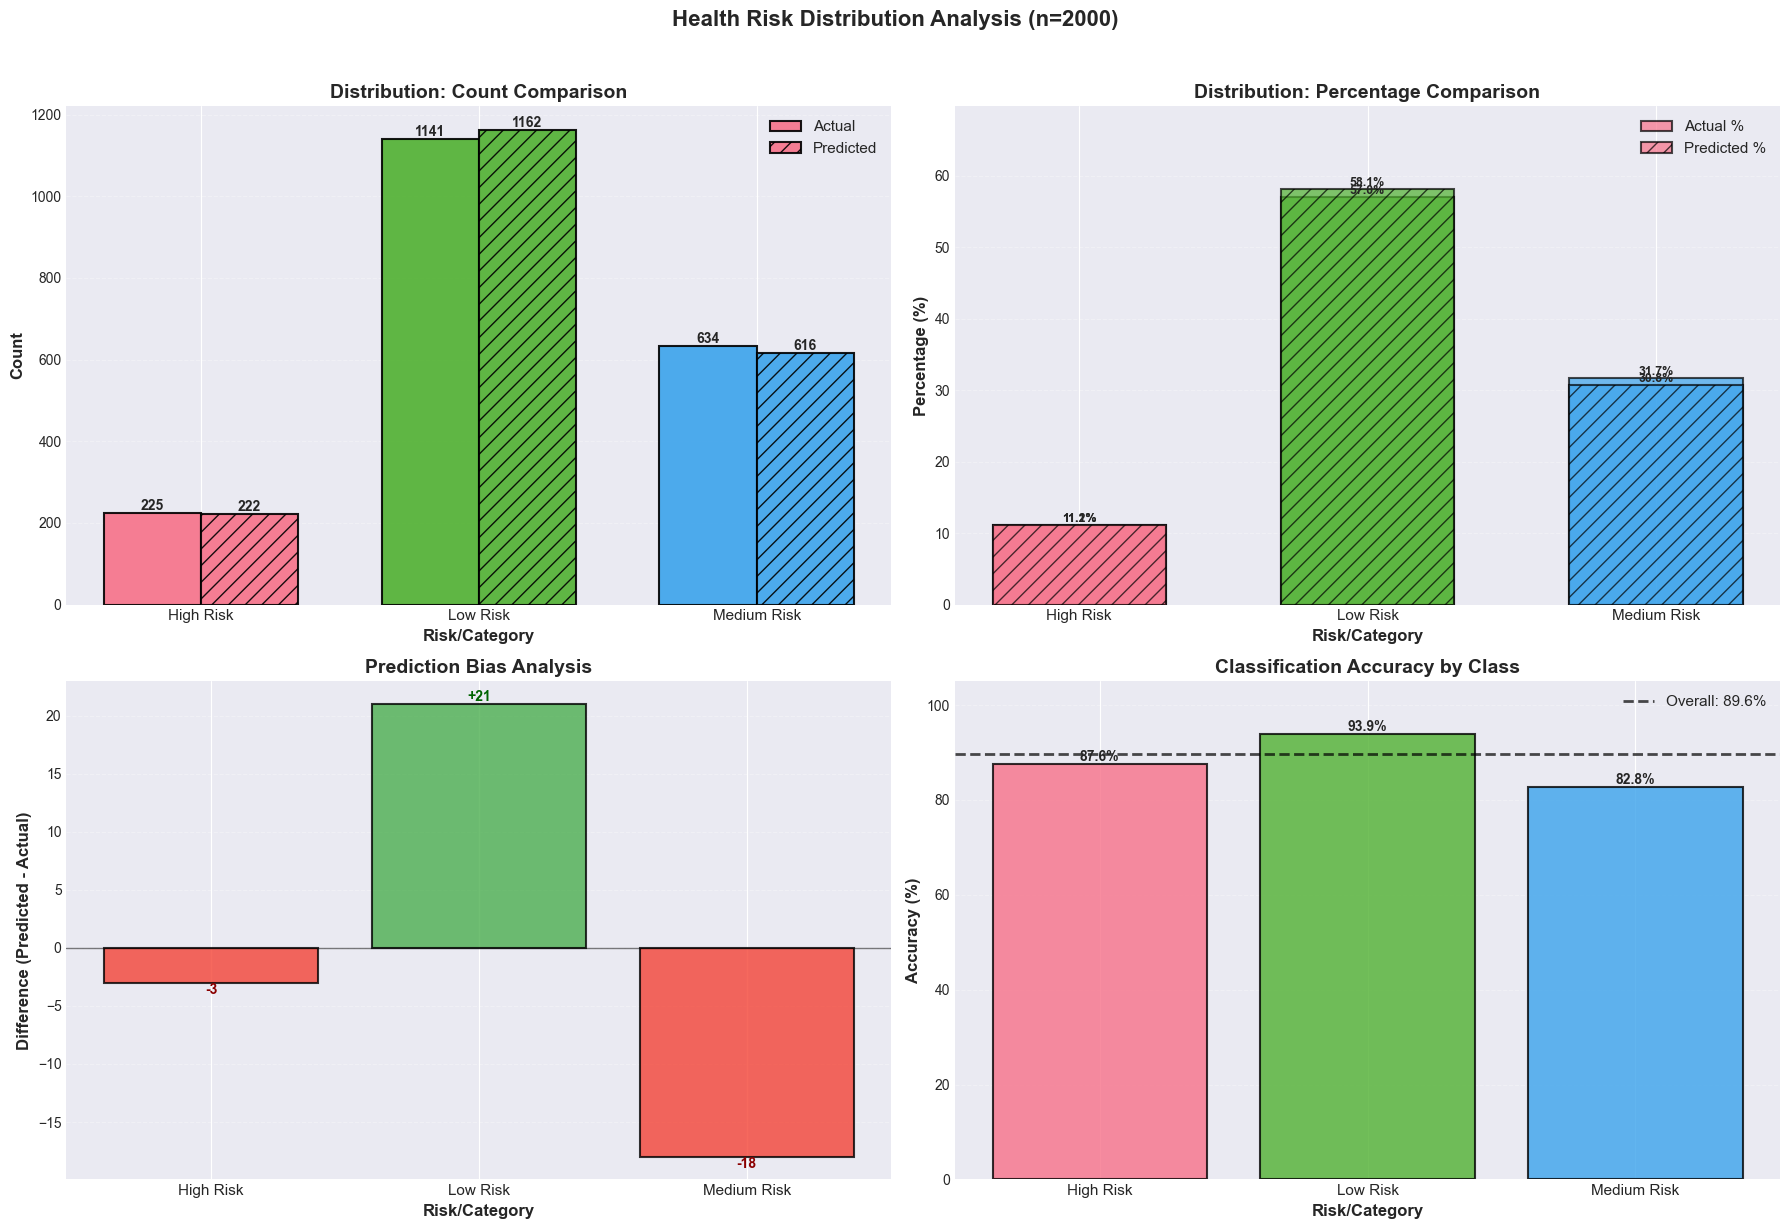

In [78]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

# ============================================
# GENERALIZED RISK DISTRIBUTION VISUALIZATION
# ============================================

def plot_risk_distribution(y_actual, y_predicted, class_names=None, 
                          title="Risk Distribution Analysis", 
                          figsize=(16, 10), color_palette='Set2'):
    """
    Generalized function to plot risk distribution for any classification problem
    
    Parameters:
    -----------
    y_actual : array-like
        Actual class labels
    y_predicted : array-like
        Predicted class labels
    class_names : list, optional
        Names of classes (if None, will use unique values from y_actual)
    title : str
        Title for the plot
    figsize : tuple
        Figure size (width, height)
    color_palette : str
        Seaborn color palette name
    """
    
    # Convert to numpy arrays if not already
    y_actual = np.array(y_actual)
    y_predicted = np.array(y_predicted)
    
    # Get unique class names
    if class_names is None:
        class_names = np.unique(y_actual)
    
    # Ensure class_names is in the same order as they appear
    class_names = list(class_names)
    
    # Calculate counts
    actual_counts = pd.Series(y_actual).value_counts()
    predicted_counts = pd.Series(y_predicted).value_counts()
    
    # Ensure all classes are present (even if count is 0)
    for cls in class_names:
        if cls not in actual_counts:
            actual_counts[cls] = 0
        if cls not in predicted_counts:
            predicted_counts[cls] = 0
    
    # Sort by the provided class order
    actual_counts = actual_counts[class_names]
    predicted_counts = predicted_counts[class_names]
    
    # Calculate percentages
    actual_percentages = (actual_counts / len(y_actual) * 100).round(1)
    predicted_percentages = (predicted_counts / len(y_predicted) * 100).round(1)
    
    # Calculate differences
    differences = predicted_counts.values - actual_counts.values
    percent_differences = predicted_percentages.values - actual_percentages.values
    
    # Set up the figure
    fig = plt.figure(figsize=figsize)
    
    # Create a color palette
    colors = sns.color_palette(color_palette, n_colors=len(class_names))
    color_dict = {cls: colors[i] for i, cls in enumerate(class_names)}
    
    # ============================================
    # 1. MAIN BAR CHART: Count Comparison
    # ============================================
    ax1 = plt.subplot(2, 2, 1)
    
    x = np.arange(len(class_names))
    width = 0.35
    
    # Create grouped bars
    bars_actual = ax1.bar(x - width/2, actual_counts.values, width, 
                         color=[color_dict[cls] for cls in class_names],
                         edgecolor='black', linewidth=1.5, alpha=0.9,
                         label='Actual')
    
    bars_predicted = ax1.bar(x + width/2, predicted_counts.values, width,
                            color=[color_dict[cls] for cls in class_names],
                            edgecolor='black', linewidth=1.5, alpha=0.9,
                            hatch='//', label='Predicted')
    
    # Customize plot 1
    ax1.set_xlabel('Risk/Category', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax1.set_title('Distribution: Count Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(class_names, fontsize=11, rotation=0)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.legend(fontsize=11, loc='best')
    
    # Add value labels
    for i, (act_val, pred_val) in enumerate(zip(actual_counts.values, predicted_counts.values)):
        ax1.text(i - width/2, act_val, str(act_val),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax1.text(i + width/2, pred_val, str(pred_val),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # ============================================
    # 2. PERCENTAGE BAR CHART
    # ============================================
    ax2 = plt.subplot(2, 2, 2)
    
    # Stack actual and predicted percentages
    bars2_actual = ax2.bar(x, actual_percentages.values, width=0.6,
                          color=[color_dict[cls] for cls in class_names],
                          edgecolor='black', linewidth=1.5, alpha=0.7,
                          label='Actual %')
    
    bars2_pred = ax2.bar(x, predicted_percentages.values, width=0.6,
                        color=[color_dict[cls] for cls in class_names],
                        edgecolor='black', linewidth=1.5, alpha=0.7,
                        hatch='//', label='Predicted %')
    
    # Customize plot 2
    ax2.set_xlabel('Risk/Category', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Distribution: Percentage Comparison', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(class_names, fontsize=11, rotation=0)
    ax2.set_ylim(0, max(actual_percentages.max(), predicted_percentages.max()) * 1.2)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.legend(fontsize=11, loc='best')
    
    # Add percentage labels
    for i, (act_pct, pred_pct) in enumerate(zip(actual_percentages.values, predicted_percentages.values)):
        ax2.text(i, act_pct, f'{act_pct}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax2.text(i, pred_pct, f'{pred_pct}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # ============================================
    # 3. DIFFERENCE PLOT
    # ============================================
    ax3 = plt.subplot(2, 2, 3)
    
    # Plot differences (Predicted - Actual)
    bars_diff = ax3.bar(x, differences,
                       color=['#4CAF50' if diff >= 0 else '#F44336' for diff in differences],
                       edgecolor='black', linewidth=1.5, alpha=0.8)
    
    # Add horizontal line at zero
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    # Customize plot 3
    ax3.set_xlabel('Risk/Category', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Difference (Predicted - Actual)', fontsize=12, fontweight='bold')
    ax3.set_title('Prediction Bias Analysis', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(class_names, fontsize=11, rotation=0)
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add difference labels
    for i, diff in enumerate(differences):
        va = 'bottom' if diff >= 0 else 'top'
        color = 'darkgreen' if diff >= 0 else 'darkred'
        ax3.text(i, diff, f'{diff:+d}',
                ha='center', va=va, fontsize=10, fontweight='bold', color=color)
    
    # ============================================
    # 4. ACCURACY BY CLASS
    # ============================================
    ax4 = plt.subplot(2, 2, 4)
    
    # Calculate accuracy for each class
    class_accuracy = []
    for cls in class_names:
        mask = y_actual == cls
        if mask.any():
            accuracy = (y_actual[mask] == y_predicted[mask]).mean() * 100
        else:
            accuracy = 0
        class_accuracy.append(accuracy)
    
    # Plot accuracy bars
    bars_acc = ax4.bar(x, class_accuracy,
                      color=[color_dict[cls] for cls in class_names],
                      edgecolor='black', linewidth=1.5, alpha=0.8)
    
    # Add horizontal line at overall accuracy
    overall_acc = (y_actual == y_predicted).mean() * 100
    ax4.axhline(y=overall_acc, color='black', linestyle='--', linewidth=2,
                alpha=0.7, label=f'Overall: {overall_acc:.1f}%')
    
    # Customize plot 4
    ax4.set_xlabel('Risk/Category', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax4.set_title('Classification Accuracy by Class', fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(class_names, fontsize=11, rotation=0)
    ax4.set_ylim(0, 105)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')
    ax4.legend(fontsize=11, loc='best')
    
    # Add accuracy labels
    for i, acc in enumerate(class_accuracy):
        ax4.text(i, acc, f'{acc:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # ============================================
    # MAIN TITLE AND LAYOUT
    # ============================================
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    return fig, (ax1, ax2, ax3, ax4)

# ============================================
# GENERATE SUMMARY STATISTICS TABLE
# ============================================

def generate_distribution_summary(y_actual, y_predicted, class_names=None):
    """
    Generate a comprehensive summary table of the distribution
    """
    y_actual = np.array(y_actual)
    y_predicted = np.array(y_predicted)
    
    if class_names is None:
        class_names = np.unique(y_actual)
    
    class_names = list(class_names)
    
    # Calculate statistics
    summary_data = []
    for cls in class_names:
        actual_count = (y_actual == cls).sum()
        predicted_count = (y_predicted == cls).sum()
        actual_pct = (actual_count / len(y_actual) * 100)
        predicted_pct = (predicted_count / len(y_predicted) * 100)
        difference = predicted_count - actual_count
        percent_diff = predicted_pct - actual_pct
        
        # Calculate class accuracy
        mask = y_actual == cls
        if mask.any():
            class_acc = (y_actual[mask] == y_predicted[mask]).mean() * 100
        else:
            class_acc = np.nan
        
        summary_data.append({
            'Class': cls,
            'Actual Count': actual_count,
            'Actual %': f"{actual_pct:.1f}%",
            'Predicted Count': predicted_count,
            'Predicted %': f"{predicted_pct:.1f}%",
            'Count Diff': f"{difference:+d}",
            '% Diff': f"{percent_diff:+.1f}%",
            'Class Accuracy': f"{class_acc:.1f}%"
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Add overall statistics
    overall_acc = (y_actual == y_predicted).mean() * 100
    total_actual = len(y_actual)
    total_predicted = len(y_predicted)
    
    return summary_df, overall_acc, total_actual, total_predicted

# ============================================
# EXECUTE THE VISUALIZATION
# ============================================

# Using your data
print("=" * 80)
print("GENERALIZED RISK DISTRIBUTION ANALYSIS")
print("=" * 80)

# Generate the visualization
fig, axes = plot_risk_distribution(
    y_actual=y_test_labels,
    y_predicted=y_pred_labels,
    class_names=label_encoder.classes_,
    title=f"Health Risk Distribution Analysis (n={len(y_test_labels)})",
    figsize=(18, 12),
    color_palette='husl'
)

# Generate summary statistics
summary_df, overall_acc, total_actual, total_predicted = generate_distribution_summary(
    y_actual=y_test_labels,
    y_predicted=y_pred_labels,
    class_names=label_encoder.classes_
)

# Display the summary
print("\n📊 DISTRIBUTION SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)

# Display overall statistics
print(f"\n📈 OVERALL STATISTICS")
print("-" * 40)
print(f"Total Samples: {total_actual}")
print(f"Overall Accuracy: {overall_acc:.2f}%")
print(f"Correct Predictions: {(y_test_labels == y_pred_labels).sum()}/{total_actual}")

# Calculate additional metrics
from sklearn.metrics import balanced_accuracy_score
balanced_acc = balanced_accuracy_score(y_test_labels, y_pred_labels) * 100
print(f"Balanced Accuracy: {balanced_acc:.2f}%")

# Show the plot
plt.show()

# Save the figure (optional)
# fig.savefig('risk_distribution_analysis.png', dpi=300, bbox_inches='tight')
# print("\nFigure saved as 'risk_distribution_analysis.png'")